<a href="https://colab.research.google.com/github/Viktoriia-code26/nlp-extractive-summarization/blob/main/DS_ML_Hw_12.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import spacy
import nltk
import matplotlib.pyplot as plt

from collections import Counter
from heapq import nlargest
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize, sent_tokenize
from string import punctuation

In [ ]:
# Намагаємося підготувати стандартні ресурси NLTK.
# Якщо середовище без доступу до мережі, нижче передбачено fallback.
for resource in ('punkt', 'punkt_tab', 'stopwords'):
    try:
        nltk.download(resource, quiet=True)
    except Exception:
        pass

# Для цього завдання достатньо базового англійського pipeline spaCy.
try:
    nlp = spacy.load('en_core_web_sm')
except OSError:
    nlp = spacy.blank('en')

if 'sentencizer' not in nlp.pipe_names and 'parser' not in nlp.pipe_names and 'senter' not in nlp.pipe_names:
    nlp.add_pipe('sentencizer')

print('NLTK і spaCy готові до роботи.')

NLTK і spaCy готові до роботи.


In [ ]:
text = 'The Orbiter Discovery, OV-103, is considered eligible for listing in the National Register of Historic Places (NRHP) in the context of the U.S. Space Shuttle Program (1969-2011) under Criterion A in the areas of Space Exploration and Transportation and under Criterion C in the area of Engineering. Because it has achieved significance within the past fifty years, Criteria Consideration G applies. Under Criterion A, Discovery is significant as the oldest of the three extant orbiter vehicles constructed for the Space Shuttle Program (SSP), the longest running American space program to date; she was the third of five orbiters built by NASA. Unlike the Mercury, Gemini, and Apollo programs, the SSP’s emphasis was on cost effectiveness and reusability, and eventually the construction of a space station. Including her maiden voyage (launched August 30, 1984), Discovery flew to space thirty-nine times, more than any of the other four orbiters; she was also the first orbiter to fly twenty missions. She had the honor of being chosen as the Return to Flight vehicle after both the Challenger and Columbia accidents. Discovery was the first shuttle to fly with the redesigned SRBs, a result of the Challenger accident, and the first shuttle to fly with the Phase II and Block I SSME. Discovery also carried the Hubble Space Telescope to orbit and performed two of the five servicing missions to the observatory. She flew the first and last dedicated Department of Defense (DoD) missions, as well as the first unclassified defense-related mission. In addition, Discovery was vital to the construction of the International Space Station (ISS); she flew thirteen of the thirty-seven total missions flown to the station by a U.S. Space Shuttle. She was the first orbiter to dock to the ISS, and the first to perform an exchange of a resident crew. Under Criterion C, Discovery is significant as a feat of engineering. According to Wayne Hale, a flight director from Johnson Space Center, the Space Shuttle orbiter represents a “huge technological leap from expendable rockets and capsules to a reusable, winged, hypersonic, cargo-carrying spacecraft.” Although her base structure followed a conventional aircraft design, she used advanced materials that both minimized her weight for cargo-carrying purposes and featured low thermal expansion ratios, which provided a stable base for her Thermal Protection System (TPS) materials. The Space Shuttle orbiter also featured the first reusable TPS; all previous spaceflight vehicles had a single-use, ablative heat shield. Other notable engineering achievements of the orbiter included the first reusable orbital propulsion system, and the first two-fault-tolerant Integrated Avionics System. As Hale stated, the Space Shuttle remains “the largest, fastest, winged hypersonic aircraft in history,” having regularly flown at twenty-five times the speed of sound.'

In [ ]:
# Токенізація двома бібліотеками
doc = nlp(text)
spacy_tokens = [token.text for token in doc]

# NLTK word_tokenize з preserve_line=True не потребує punkt.
nltk_tokens = word_tokenize(text, preserve_line=True)

# Для речень використовуємо NLTK, а якщо punkt_tab відсутній — spaCy.
try:
    sentences = sent_tokenize(text)
except LookupError:
    sentences = [sent.text.strip() for sent in doc.sents]

# Stop words: пріоритет NLTK, fallback — вбудований список spaCy.
try:
    stop_words = set(stopwords.words('english'))
except LookupError:
    from spacy.lang.en.stop_words import STOP_WORDS
    stop_words = set(STOP_WORDS)

print(f'Кількість токенів spaCy: {len(spacy_tokens)}')
print(f'Кількість токенів NLTK: {len(nltk_tokens)}')
print(f'Кількість речень: {len(sentences)}')

Кількість токенів spaCy: 539
Кількість токенів NLTK: 504
Кількість речень: 16


In [ ]:
# Рахуємо частоти змістовних слів.
# ВАЖЛИВО: ключі зберігаємо в lower case, щоб підрахунок був узгодженим.
word_frequencies = Counter(
    token.text.lower()
    for token in doc
    if not token.is_space
    and not token.is_punct
    and token.text.lower() not in stop_words
)

# Нормалізація частот до діапазону 0..1
max_frequency = max(word_frequencies.values())
normalized_frequencies = {
    word: freq / max_frequency
    for word, freq in word_frequencies.items()
}

word_frequencies.most_common(15)

[('space', 13),
 ('first', 10),
 ('shuttle', 8),
 ('orbiter', 7),
 ('discovery', 7),
 ('criterion', 4),
 ('missions', 4),
 ('program', 3),
 ('engineering', 3),
 ('five', 3),
 ('station', 3),
 ('flew', 3),
 ('also', 3),
 ('fly', 3),
 ('reusable', 3)]

In [ ]:
# Оцінюємо кожне речення сумою нормалізованих частот його змістовних слів.
sentence_scores = {}
for sentence in sentences:
    words = word_tokenize(sentence.lower(), preserve_line=True)
    score = sum(normalized_frequencies.get(word, 0) for word in words)
    sentence_scores[sentence] = score

# Беремо приблизно 30% речень, але не менше одного.
select_length = max(1, round(len(sentences) * 0.30))

# Спочатку обираємо найвагоміші речення...
selected_sentences = nlargest(
    select_length,
    sentence_scores,
    key=sentence_scores.get
)

# ...потім повертаємо їх у початковий порядок, щоб summary читалося природно.
summary_sentences = [s for s in sentences if s in selected_sentences]
summary = ' '.join(summary_sentences)

print(summary)

The Orbiter Discovery, OV-103, is considered eligible for listing in the National Register of Historic Places (NRHP) in the context of the U.S. Space Shuttle Program (1969-2011) under Criterion A in the areas of Space Exploration and Transportation and under Criterion C in the area of Engineering. Under Criterion A, Discovery is significant as the oldest of the three extant orbiter vehicles constructed for the Space Shuttle Program (SSP), the longest running American space program to date; she was the third of five orbiters built by NASA. Including her maiden voyage (launched August 30, 1984), Discovery flew to space thirty-nine times, more than any of the other four orbiters; she was also the first orbiter to fly twenty missions. In addition, Discovery was vital to the construction of the International Space Station (ISS); she flew thirteen of the thirty-seven total missions flown to the station by a U.S. Space Shuttle. According to Wayne Hale, a flight director from Johnson Space Cen

## Summary

In [ ]:
print(summary)

The Orbiter Discovery, OV-103, is considered eligible for listing in the National Register of Historic Places (NRHP) in the context of the U.S. Space Shuttle Program (1969-2011) under Criterion A in the areas of Space Exploration and Transportation and under Criterion C in the area of Engineering. Under Criterion A, Discovery is significant as the oldest of the three extant orbiter vehicles constructed for the Space Shuttle Program (SSP), the longest running American space program to date; she was the third of five orbiters built by NASA. Including her maiden voyage (launched August 30, 1984), Discovery flew to space thirty-nine times, more than any of the other four orbiters; she was also the first orbiter to fly twenty missions. In addition, Discovery was vital to the construction of the International Space Station (ISS); she flew thirteen of the thirty-seven total missions flown to the station by a U.S. Space Shuttle. According to Wayne Hale, a flight director from Johnson Space Cen

In [ ]:
# Зберігаємо summary у текстовий файл.
with open('summary.txt', 'w', encoding='utf-8') as f:
    f.write(summary)

print('Summary saved to summary.txt')

Summary saved to summary.txt


In [ ]:
original_word_count = len(word_tokenize(text, preserve_line=True))
summary_word_count = len(word_tokenize(summary, preserve_line=True))
compression_ratio = summary_word_count / original_word_count

print(f'Кількість слів в оригінальному тексті: {original_word_count}')
print(f'Кількість слів у summary: {summary_word_count}')
print(f'Співвідношення стиснення: {compression_ratio:.2f}')

Кількість слів в оригінальному тексті: 504
Кількість слів у summary: 254
Співвідношення стиснення: 0.50


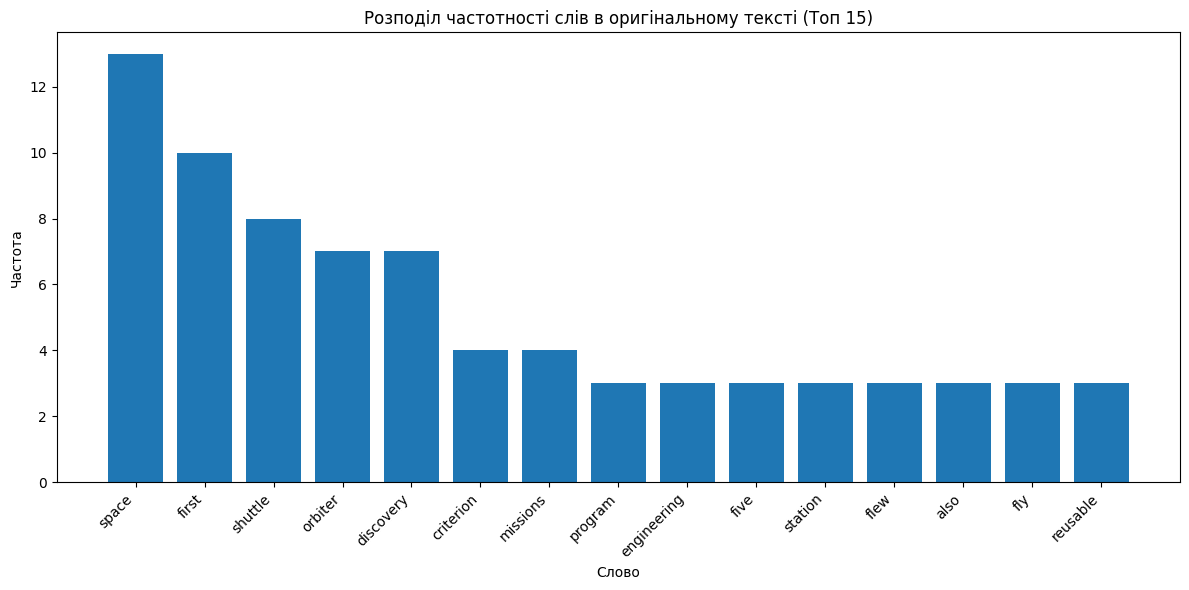

In [ ]:
# Топ-15 найчастотніших змістовних слів
top_words = word_frequencies.most_common(15)
words = [word for word, _ in top_words]
counts = [count for _, count in top_words]

plt.figure(figsize=(12, 6))
plt.bar(words, counts)
plt.title('Розподіл частотності слів в оригінальному тексті (Топ 15)')
plt.xlabel('Слово')
plt.ylabel('Частота')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Порівняння оригінального тексту та summary


In [ ]:
import pandas as pd
from IPython.display import display

compression_percent = (1 - summary_word_count / original_word_count) * 100

comparison_df = pd.DataFrame({
    'Original Text': [text],
    'Generated Summary': [summary],
    'Original Words': [original_word_count],
    'Summary Words': [summary_word_count],
    'Compression %': [round(compression_percent, 2)]
})

display(comparison_df)


,Original Text,Generated Summary,Original Words,Summary Words,Compression %
0,"The Orbiter Discovery, OV-103, is considered e...","The Orbiter Discovery, OV-103, is considered e...",504,254,49.6


### Висновок

NLTK використовується для токенізації речень/слів і stop words, а spaCy — для NLP-токенізації та фільтрації пунктуації/пробілів. Summary формується extractive-методом: важливість речення визначається частотами змістовних слів у всьому тексті.